In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [25]:
DATA_FILE = "../data/processed/model2_dataset.csv"
MODEL_FILE = "../models/elastic_net_model2.pkl"

data = pd.read_csv(DATA_FILE)
model = joblib.load(MODEL_FILE)

print("Dataset loaded successfully")
print("Model loaded successfully")

Dataset loaded successfully
Model loaded successfully


In [26]:
numeric_features = [
    "budget",
    "log_budget",
    "runtime",
    "release_year",
    "release_month",
    "cast_count",
    "production_company_count",
    "director_previous_movies"
]

categorical_features = [
    "original_language",
    "main_country"
]

genre_features = [
    column
    for column in data.columns
    if column.startswith("genre_")
]

numeric_features.extend(genre_features)

features = numeric_features + categorical_features

In [27]:
test_data = data[
    data["release_year"] > 2015
].copy()

X_test = test_data[features]
y_test = test_data["log_revenue"]

In [28]:
predicted_log_revenue = model.predict(
    X_test
)

predicted_revenue = np.expm1(
    predicted_log_revenue
)

actual_revenue = np.expm1(
    y_test
)

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    actual_revenue,
    predicted_revenue
)

rmse = np.sqrt(
    mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

r2 = r2_score(
    actual_revenue,
    predicted_revenue
)

rmsle = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_log_revenue
    )
)

print("==============================")
print("MODEL 2 EVALUATION")
print("==============================")

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("RMSLE:", rmsle)

MODEL 2 EVALUATION
MAE: 89213393.31152348
RMSE: 182175263.75786108
R2: 0.41308920680690653
RMSLE: 1.6462196291868447


# MODEL 1

In [9]:
mae = mean_absolute_error(
    actual_revenue,
    predicted_revenue
)

rmse = np.sqrt(
    mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

r2 = r2_score(
    actual_revenue,
    predicted_revenue
)

rmsle = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_log_revenue
    )
)

In [10]:
print("==============================")
print("MODEL EVALUATION")
print("==============================")

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))
print("RMSLE:", round(rmsle, 4))

MODEL EVALUATION
MAE: 85782170.07
RMSE: 173699896.19
R2: 0.4664
RMSLE: 1.5869


In [11]:
metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "RMSLE"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        rmsle
    ]
})

metrics.to_csv(
    "../results/metrics.csv",
    index=False
)

print("Metrics saved successfully.")

Metrics saved successfully.


In [12]:
predictions = pd.DataFrame({
    "actual_revenue": actual_revenue,
    "predicted_revenue": predicted_revenue
})

predictions.to_csv(
    "../results/predictions.csv",
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.


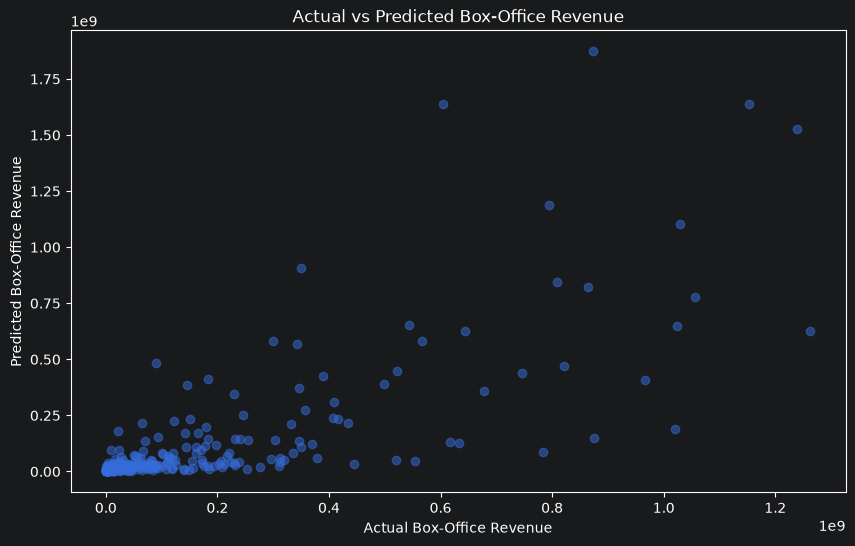

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    actual_revenue,
    predicted_revenue,
    alpha=0.5
)

plt.xlabel("Actual Box-Office Revenue")
plt.ylabel("Predicted Box-Office Revenue")
plt.title("Actual vs Predicted Box-Office Revenue")

plt.show()

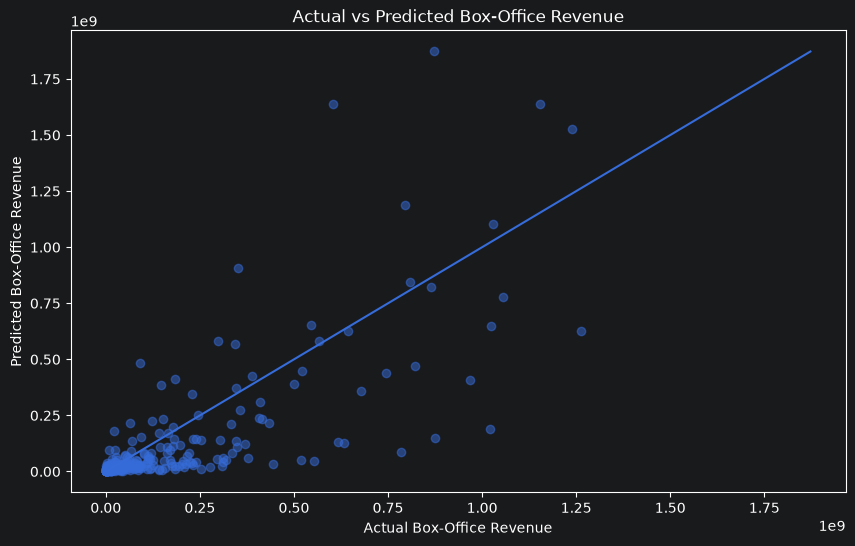

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(
    actual_revenue,
    predicted_revenue,
    alpha=0.5
)

minimum = min(
    actual_revenue.min(),
    predicted_revenue.min()
)

maximum = max(
    actual_revenue.max(),
    predicted_revenue.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Box-Office Revenue")
plt.ylabel("Predicted Box-Office Revenue")
plt.title("Actual vs Predicted Box-Office Revenue")

plt.show()

In [15]:
preprocessor = model.named_steps["preprocessor"]
elastic_net = model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

coefficients = elastic_net.coef_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Absolute_Coefficient
117,categorical__main_country_Unknown,-2.346938,2.346938
48,categorical__original_language_sr,-2.136942,2.136942
1,numeric__log_budget,1.639856,1.639856
103,categorical__main_country_Serbia,-1.264314,1.264314
26,categorical__original_language_de,-0.848820,0.848820
91,categorical__main_country_Mexico,0.819727,0.819727
77,categorical__main_country_Hong Kong,0.810521,0.810521
71,categorical__main_country_Denmark,-0.724185,0.724185
32,categorical__original_language_fr,-0.711132,0.711132
62,categorical__main_country_Belgium,-0.673646,0.673646


In [16]:
top_features = feature_importance.head(20)

print(top_features[
    ["Feature", "Coefficient"]
].to_string(index=False))

                                           Feature  Coefficient
                 categorical__main_country_Unknown    -2.346938
                 categorical__original_language_sr    -2.136942
                               numeric__log_budget     1.639856
                  categorical__main_country_Serbia    -1.264314
                 categorical__original_language_de    -0.848820
                  categorical__main_country_Mexico     0.819727
               categorical__main_country_Hong Kong     0.810521
                 categorical__main_country_Denmark    -0.724185
                 categorical__original_language_fr    -0.711132
                 categorical__main_country_Belgium    -0.673646
                 categorical__original_language_it    -0.622820
                   categorical__main_country_Italy    -0.457249
                 categorical__original_language_nl     0.390921
categorical__main_country_United States of America     0.381564
                  categorical__main_coun

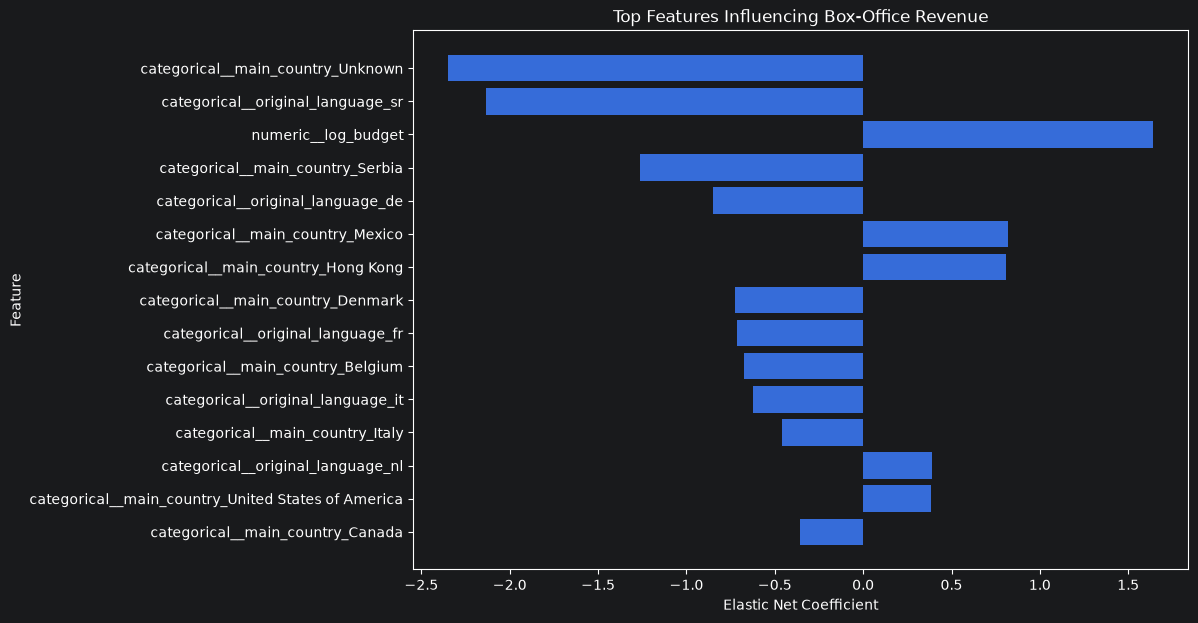

In [17]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Elastic Net Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Box-Office Revenue")

plt.gca().invert_yaxis()

plt.show()

In [18]:
feature_importance.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [19]:
top_positive = feature_importance[
    feature_importance["Coefficient"] > 0
].head(10)

top_negative = feature_importance[
    feature_importance["Coefficient"] < 0
].sort_values(
    "Coefficient"
).head(10)

In [20]:
print("Top Positive Features")
print(
    top_positive[
        ["Feature", "Coefficient"]
    ].to_string(index=False)
)

Top Positive Features
                                           Feature  Coefficient
                               numeric__log_budget     1.639856
                  categorical__main_country_Mexico     0.819727
               categorical__main_country_Hong Kong     0.810521
                 categorical__original_language_nl     0.390921
categorical__main_country_United States of America     0.381564
                                   numeric__budget     0.344372
                   categorical__main_country_Japan     0.300508
          categorical__main_country_United Kingdom     0.296387
                   categorical__main_country_India     0.266248
                                  numeric__runtime     0.242376


In [21]:
print("\nTop Negative Features")
print(
    top_negative[
        ["Feature", "Coefficient"]
    ].to_string(index=False)
)


Top Negative Features
                          Feature  Coefficient
categorical__main_country_Unknown    -2.346938
categorical__original_language_sr    -2.136942
 categorical__main_country_Serbia    -1.264314
categorical__original_language_de    -0.848820
categorical__main_country_Denmark    -0.724185
categorical__original_language_fr    -0.711132
categorical__main_country_Belgium    -0.673646
categorical__original_language_it    -0.622820
  categorical__main_country_Italy    -0.457249
 categorical__main_country_Canada    -0.359616


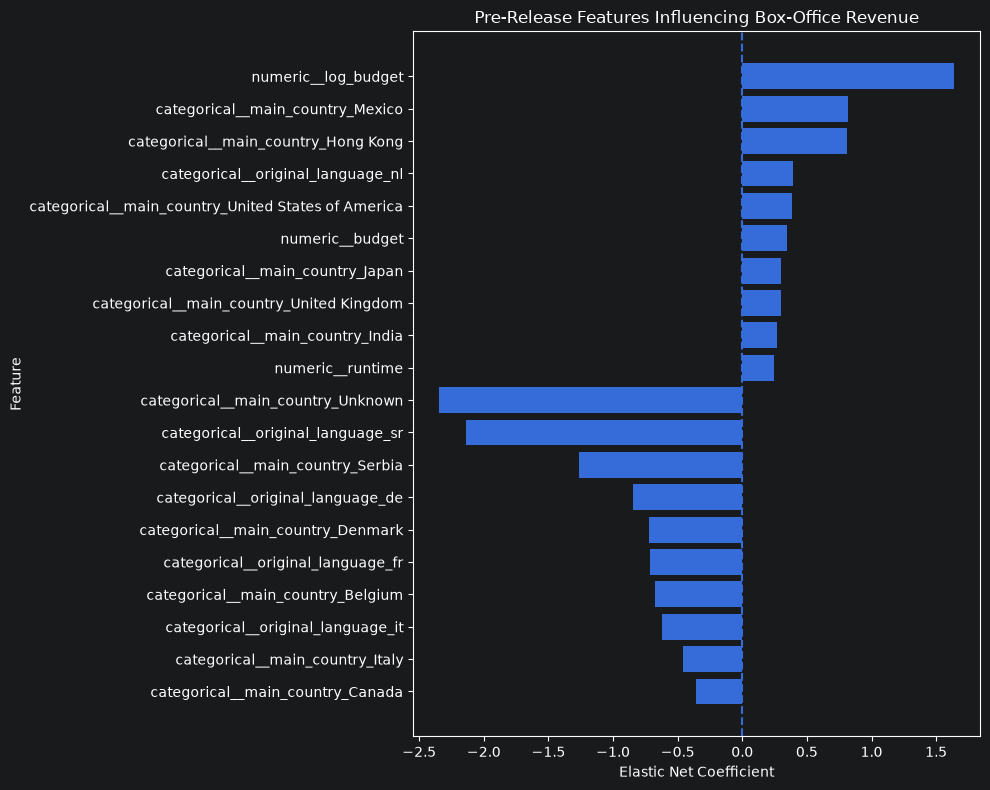

In [22]:
top_features = pd.concat([
    top_positive,
    top_negative
])

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Elastic Net Coefficient")
plt.ylabel("Feature")
plt.title("Pre-Release Features Influencing Box-Office Revenue")

plt.axvline(
    0,
    linestyle="--"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../results/plots/feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

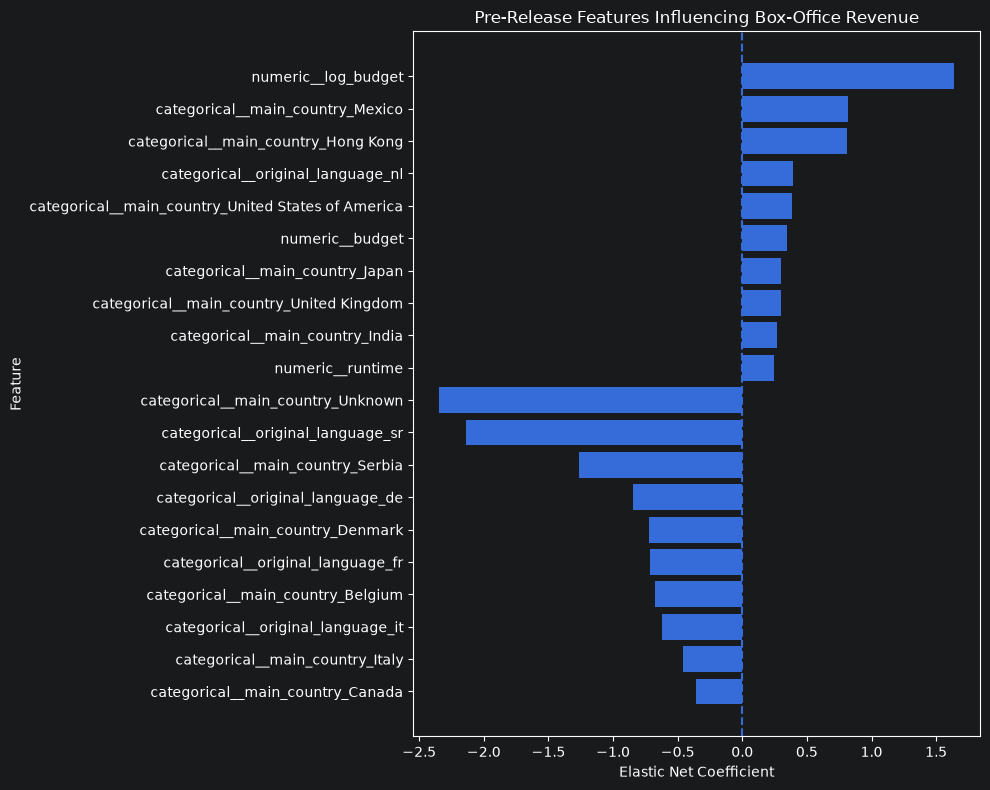

In [23]:
top_features = pd.concat([
    top_positive,
    top_negative
])

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Elastic Net Coefficient")
plt.ylabel("Feature")
plt.title("Pre-Release Features Influencing Box-Office Revenue")

plt.axvline(
    0,
    linestyle="--"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../results/plots/feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
baseline_results = {
    "Model": "Elastic Net - Basic Pre-Release Features",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "RMSLE": rmsle
}

print(baseline_results)

{'Model': 'Elastic Net - Basic Pre-Release Features', 'MAE': 85782170.06804797, 'RMSE': np.float64(173699896.1927403), 'R2': 0.4664287754986396, 'RMSLE': np.float64(1.5869158604909332)}


MODEL 3

In [30]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

DATA_FILE = "../data/processed/model3_dataset.csv"
MODEL_FILE = "../models/elastic_net_model3.pkl"

data = pd.read_csv(DATA_FILE)
model = joblib.load(MODEL_FILE)

numeric_features = [
    "budget",
    "log_budget",
    "runtime",
    "release_year",
    "release_month",
    "director_previous_movies",
    "director_previous_avg_log_revenue"
]

categorical_features = [
    "original_language",
    "main_country"
]

features = numeric_features + categorical_features

test_data = data[
    data["release_year"] > 2015
].copy()

X_test = test_data[features]
y_test = test_data["log_revenue"]

predicted_log_revenue = model.predict(X_test)

predicted_revenue = np.expm1(
    predicted_log_revenue
)

actual_revenue = np.expm1(
    y_test
)

mae = mean_absolute_error(
    actual_revenue,
    predicted_revenue
)

rmse = np.sqrt(
    mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

r2 = r2_score(
    actual_revenue,
    predicted_revenue
)

rmsle = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_log_revenue
    )
)

print("==============================")
print("MODEL 3 EVALUATION")
print("==============================")

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("RMSLE:", rmsle)

MODEL 3 EVALUATION
MAE: 90904942.57804638
RMSE: 190098443.7857271
R2: 0.36092709439955295
RMSLE: 1.6592131441555444


MODEL 4

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

MODEL_FILE = "../models/elastic_net_model4.pkl"
DATA_FILE = "../data/processed/model4_dataset.csv"

model = joblib.load(MODEL_FILE)
data = pd.read_csv(DATA_FILE)

print("Model loaded successfully.")
print("Dataset shape:", data.shape)

Model loaded successfully.
Dataset shape: (5381, 27)


In [2]:
genre_columns = [
    column
    for column in data.columns
    if column.startswith("genre_")
]

numeric_features = [
    "budget",
    "log_budget",
    "runtime",
    "release_year",
    "release_month"
]

numeric_features.extend(genre_columns)

categorical_features = [
    "original_language",
    "main_country"
]

feature_columns = (
    numeric_features
    + categorical_features
)

target = "log_revenue"

test_data = data[
    data["release_year"] > 2015
].copy()

X_test = test_data[feature_columns]
y_test = test_data[target]

print("Test data shape:", X_test.shape)

Test data shape: (306, 25)


In [3]:
predicted_log_revenue = model.predict(X_test)

predicted_revenue = np.expm1(
    predicted_log_revenue
)

actual_revenue = np.expm1(
    y_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [4]:
mae = mean_absolute_error(
    actual_revenue,
    predicted_revenue
)

rmse = np.sqrt(
    mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

r2 = r2_score(
    actual_revenue,
    predicted_revenue
)

rmsle = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_log_revenue
    )
)

print("Final Model 4 Evaluation")
print("-------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("RMSLE:", rmsle)

Final Model 4 Evaluation
-------------------------
MAE: 83460551.04862802
RMSE: 168851393.20838276
R2: 0.49580030455372504
RMSLE: 1.6289945558925885


In [5]:
comparison = pd.DataFrame({
    "Actual Revenue": actual_revenue.values,
    "Predicted Revenue": predicted_revenue
})

comparison["Error"] = (
    comparison["Predicted Revenue"]
    - comparison["Actual Revenue"]
)

print(comparison.head(10))

   Actual Revenue  Predicted Revenue         Error
0       1397284.0       1.070464e+07  9.307352e+06
1       2400000.0       1.237953e+07  9.979525e+06
2       9200000.0       5.909043e+06 -3.290957e+06
3      40055439.0       1.287756e+07 -2.717788e+07
4      69411370.0       4.688886e+07 -2.252251e+07
5      17062499.0       2.835877e+07  1.129627e+07
6     109906372.0       3.509952e+07 -7.480685e+07
7     124827316.0       4.126321e+07 -8.356411e+07
8     112343513.0       4.247124e+07 -6.987227e+07
9      94073028.0       1.311421e+07 -8.095882e+07


In [6]:
results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "RMSLE"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        rmsle
    ]
})

results.to_csv(
    "../results/model4_metrics.csv",
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.
